In [1]:
import pandas as pd

df = pd.read_csv("Hitters.csv")

df.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   AtBat      322 non-null    int64  
 1   Hits       322 non-null    int64  
 2   HmRun      322 non-null    int64  
 3   Runs       322 non-null    int64  
 4   RBI        322 non-null    int64  
 5   Walks      322 non-null    int64  
 6   Years      322 non-null    int64  
 7   CAtBat     322 non-null    int64  
 8   CHits      322 non-null    int64  
 9   CHmRun     322 non-null    int64  
 10  CRuns      322 non-null    int64  
 11  CRBI       322 non-null    int64  
 12  CWalks     322 non-null    int64  
 13  League     322 non-null    str    
 14  Division   322 non-null    str    
 15  PutOuts    322 non-null    int64  
 16  Assists    322 non-null    int64  
 17  Errors     322 non-null    int64  
 18  Salary     263 non-null    float64
 19  NewLeague  322 non-null    str    
dtypes: float64(1), int64(

In [3]:
df.dropna(inplace=True)

In [4]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline

df = pd.get_dummies(df, drop_first=False)

X, y = df.drop("Salary", axis="columns"), df["Salary"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

pipeline = make_pipeline(StandardScaler(), LassoCV(max_iter=10000))

X_train.head()


,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,...,CWalks,PutOuts,Assists,Errors,League_A,League_N,Division_E,Division_W,NewLeague_A,NewLeague_N
244,466,108,33,75,86,72,3,652,142,44,...,102,286,8,8,True,False,True,False,True,False
309,600,139,0,94,29,60,2,1236,309,1,...,110,300,12,9,False,True,True,False,False,True
276,581,145,17,66,68,21,2,831,210,21,...,40,320,465,32,False,True,True,False,False,True
82,677,238,31,117,113,53,5,2223,737,93,...,171,1377,100,6,True,False,True,False,True,False
188,279,64,0,31,26,30,1,279,64,0,...,30,107,205,16,False,True,False,True,False,True


In [5]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('lassocv', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",'deprecated'
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True


In [11]:
print(pipeline.named_steps["lassocv"].coef_)
df.columns

#df_vis = pd.DataFrame(pipeline.get_params()["lassocv"].coef_, columns=df.columns.names)

[-0.00000000e+00  1.21274587e+02  0.00000000e+00  0.00000000e+00
  0.00000000e+00  5.53442913e+01 -0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  4.87431480e+01  1.52413387e+02
  0.00000000e+00  7.69411275e+01 -0.00000000e+00 -1.96673272e+01
 -4.83916336e+00  3.89783444e-14  4.52942566e+01 -0.00000000e+00
 -0.00000000e+00  0.00000000e+00]


Index(['AtBat', 'Hits', 'HmRun', 'Runs', 'RBI', 'Walks', 'Years', 'CAtBat',
       'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks', 'PutOuts', 'Assists',
       'Errors', 'Salary', 'League_A', 'League_N', 'Division_E', 'Division_W',
       'NewLeague_A', 'NewLeague_N'],
      dtype='str')

In [7]:
print("Hits, RBI, Walks, CHmRun, Cruns, putOuts, Division_E, Division_W")

Hits, RBI, Walks, CHmRun, Cruns, putOuts, Division_E, Division_W


In [27]:
from sklearn.linear_model import ElasticNetCV, RidgeCV
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import root_mean_squared_error

X, y = df[["Hits", "RBI", "Walks", "CHmRun", "CRuns", "PutOuts", "Division_E", "Division_W"]], df["Salary"]

poly_feat = PolynomialFeatures(2)
poly_X = poly_feat.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(poly_X, y, test_size=0.3, random_state=42)

pipeline2 = make_pipeline(StandardScaler(), RidgeCV())
pipeline2.fit(X_train, y_train)

y_pred = pipeline2.predict(X_test)

In [28]:
pipeline2.get_params()

{'memory': None,
 'steps': [('standardscaler', StandardScaler()), ('ridgecv', RidgeCV())],
 'transform_input': None,
 'verbose': False,
 'standardscaler': StandardScaler(),
 'ridgecv': RidgeCV(),
 'standardscaler__copy': True,
 'standardscaler__with_mean': True,
 'standardscaler__with_std': True,
 'ridgecv__alpha_per_target': False,
 'ridgecv__alphas': (0.1, 1.0, 10.0),
 'ridgecv__cv': None,
 'ridgecv__fit_intercept': True,
 'ridgecv__gcv_mode': None,
 'ridgecv__scoring': None,
 'ridgecv__store_cv_results': False}

In [29]:
root_mean_squared_error(y_test, y_pred)

351.3851049920132

In [30]:
df["Salary"].describe()

count     263.000000
mean      535.925882
std       451.118681
min        67.500000
25%       190.000000
50%       425.000000
75%       750.000000
max      2460.000000
Name: Salary, dtype: float64

<Axes: >

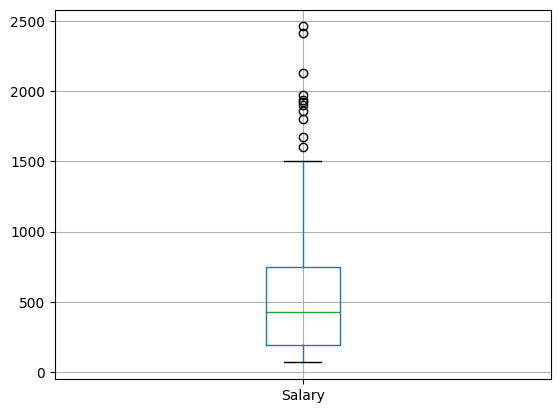

In [26]:
df.boxplot(column=["Salary"])